<a href="https://colab.research.google.com/github/Laahir/MAT-422/blob/main/MAT422_HW1_Section_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_GITHUB_USERNAME/MAT-422/blob/main/HW1/MAT422_HW1_Section_1_2.ipynb)

# MAT 422 - Homework 1 - Section 1.2: Linear Algebra Basics

**Name:** Laahir

I'm using examples based on 2D game vectors since that connects to my game development minor. Position and velocity vectors in a game are a natural fit for this section, since a lot of game math is just linear algebra with different names.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.2.1 Linear Spaces

A vector space is just a set of vectors where two things always work: you can add any two vectors in the set and get another vector still in the set this is called closure under addition, and you can multiply any vector by a scalar (a plain number) and still land inside the set ,closure under scalar multiplication.

Below I treat 2D vectors like a game character's position and velocity. Both live in R2 (the plane), so adding them or scaling them should still give a vector in R2.

In [17]:
# position and velocity of a game character
position = np.array([120, 45], dtype=float)
velocity = np.array([-8, 3], dtype=float)
speed_boost = 2.0

print("position =", position)
print("velocity =", velocity)
print("position + velocity (next frame's position) =", position + velocity)
print("speed_boost * velocity (boosted velocity) =", speed_boost * velocity)

# linear combination: where would the character be after 3 frames of velocity
knockback = np.array([15, -5], dtype=float)
result = 3 * velocity - 1 * knockback
print("3*velocity - knockback =", result)

# zero vector and additive inverse
print("zero vector =", np.zeros_like(position))
print("velocity + (-velocity) =", velocity + (-velocity))

position = [120.  45.]
velocity = [-8.  3.]
position + velocity (next frame's position) = [112.  48.]
speed_boost * velocity (boosted velocity) = [-16.   6.]
3*velocity - knockback = [-39.  14.]
zero vector = [0. 0.]
velocity + (-velocity) = [0. 0.]


Every operation above stayed inside R2. That's closure in action.

Now here's a non-example. Say I only allow positions where the x-coordinate is exactly 120 (like a character stuck on one vertical lane in a rail shooter). That set is NOT a vector space, because scaling a vector in that set usually kicks you out of it.

In [18]:
lane_position = np.array([120, 45], dtype=float)
scaled = 2 * lane_position

print("original position =", lane_position)
print("scaled position =", scaled)
print("is scaled position still on the x=120 lane?", np.isclose(scaled[0], 120))

original position = [120.  45.]
scaled position = [240.  90.]
is scaled position still on the x=120 lane? False


## 1.2.2 Orthogonality

Two vectors are orthogonal (perpendicular) when their dot product equals zero. In a game, this shows up all the time: a wall's surface direction and its normal direction (the direction pointing straight out from the wall) are orthogonal to each other.

The dot product formula is `u . v = |u||v|cos(theta)`, so if the dot product is 0, then cos(theta) is 0, which means theta is 90 degrees.

In [19]:
wall_direction = np.array([1, 0], dtype=float)   # along the wall
wall_normal = np.array([0, 1], dtype=float)      # straight out from the wall

dot_product = np.dot(wall_direction, wall_normal)
angle_deg = np.degrees(np.arccos(dot_product / (np.linalg.norm(wall_direction) * np.linalg.norm(wall_normal))))
projection = (np.dot(wall_direction, wall_normal) / np.dot(wall_normal, wall_normal)) * wall_normal

print("wall_direction . wall_normal =", dot_product)
print("angle between them (degrees) =", angle_deg)
print("projection of wall_direction onto wall_normal =", projection)

wall_direction . wall_normal = 0.0
angle between them (degrees) = 90.0
projection of wall_direction onto wall_normal = [0. 0.]


Now let's try a less obvious pair of vectors that are still orthogonal, just not lined up with the x/y axes. I'll also plot them so it's easy to see the 90 degree angle.

a . b = 0.0
(this is essentially 0, any tiny nonzero value is just floating point rounding)


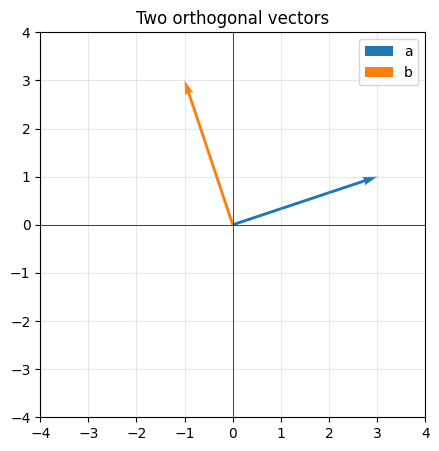

In [20]:
a = np.array([3, 1], dtype=float)
b = np.array([-1, 3], dtype=float)

dot_ab = np.dot(a, b)
print("a . b =", dot_ab)
print("(this is essentially 0, any tiny nonzero value is just floating point rounding)")

plt.figure(figsize=(5, 5))
plt.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, color="tab:blue", label="a")
plt.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1, color="tab:orange", label="b")
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.title("Two orthogonal vectors")
plt.show()

That last print statement matters more than it looks. When you compute a dot product with floating point numbers, you sometimes get something like `1.1e-16` instead of a clean `0`. That's not a mistake in the math, it's just how computers store decimal numbers. `np.isclose()` is the safe way to check "is this basically zero" instead of checking for exact equality.

## 1.2.3 Gram-Schmidt Process

Say you have a set of vectors that all point in independent directions (none of them can be built from the others), but they're not perpendicular to each other and don't have length 1. The Gram-Schmidt process turns them into an orthonormal basis: a new set of vectors that span the same space, are all mutually perpendicular, and each have length exactly 1.

The idea: take each vector, subtract off whatever part of it points along the directions you've already built, then shrink or stretch what's left so it has length 1.

In [21]:
def gram_schmidt(columns):
    basis = []
    for x in columns.T:
        y = x.astype(float).copy()
        for q in basis:
            y = y - np.dot(q, y) * q   # remove the part of y that points along q
        length = np.linalg.norm(y)
        if length < 1e-12:
            raise ValueError("vectors are not independent enough to build a basis")
        basis.append(y / length)       # shrink/stretch to length 1
    return np.column_stack(basis)

# three vectors describing three "move directions" a character could combine,
# none of which are perpendicular to each other to start
moves = np.array([
    [2, 1, 0],
    [1, 2, 1],
    [0, 1, 2],
], dtype=float)

Q = gram_schmidt(moves)
print("original move vectors (columns):")
print(moves)
print("\northonormal basis Q (columns):")
print(Q)

print("\nQ.T @ Q should look like the identity matrix if this worked:")
check = Q.T @ Q
print(check)
print("is it close to identity?", np.allclose(check, np.eye(3)))

original move vectors (columns):
[[2. 1. 0.]
 [1. 2. 1.]
 [0. 1. 2.]]

orthonormal basis Q (columns):
[[ 0.8944 -0.3586  0.2673]
 [ 0.4472  0.7171 -0.5345]
 [ 0.      0.5976  0.8018]]

Q.T @ Q should look like the identity matrix if this worked:
[[ 1.  0. -0.]
 [ 0.  1.  0.]
 [-0.  0.  1.]]
is it close to identity? True


`Q.T @ Q` coming out as the identity matrix is the real proof here. The 1's on the diagonal mean each column has length 1 (a vector dotted with itself gives its squared length). The 0's everywhere else mean every pair of columns is orthogonal. That's exactly what "orthonormal basis" means.

## 1.2.4 Eigenvalues and Eigenvectors

For a square matrix A, most vectors change both direction and length when you multiply them by A. An eigenvector is special: it only gets scaled, it never changes direction (or it flips exactly backward if the eigenvalue is negative). The scaling factor is the eigenvalue.

`A @ v = lambda * v`

A simple game example: a matrix that stretches a sprite horizontally and squishes it vertically. The horizontal and vertical axes themselves are the eigenvectors here, since stretching along x or y doesn't rotate anything, it just scales.

In [22]:
# stretch x by 1.5, squish y by 0.5 -- a simple sprite scaling transform
A = np.array([
    [1.5, 0.0],
    [0.0, 0.5],
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)
print("matrix A:")
print(A)
print("eigenvalues =", eigenvalues)
print("eigenvectors (as columns):")
print(eigenvectors)

for i, lam in enumerate(eigenvalues):
    v = eigenvectors[:, i]
    residual = A @ v - lam * v
    print(f"\neigenpair {i+1}: lambda = {lam}, v = {v}")
    print("A @ v      =", A @ v)
    print("lambda * v =", lam * v)
    print("residual norm ||A v - lambda v|| =", np.linalg.norm(residual))

matrix A:
[[1.5 0. ]
 [0.  0.5]]
eigenvalues = [1.5 0.5]
eigenvectors (as columns):
[[1. 0.]
 [0. 1.]]

eigenpair 1: lambda = 1.5, v = [1. 0.]
A @ v      = [1.5 0. ]
lambda * v = [1.5 0. ]
residual norm ||A v - lambda v|| = 0.0

eigenpair 2: lambda = 0.5, v = [0. 1.]
A @ v      = [0.  0.5]
lambda * v = [0.  0.5]
residual norm ||A v - lambda v|| = 0.0


Now a less obvious matrix, one that isn't just a diagonal scaling. This one is symmetric, which means it represents something like a "balanced" transform (imagine two forces pulling a rigid object). Symmetric matrices always have real eigenvalues, and their eigenvectors always come out orthogonal to each other, which is worth checking directly.

In [23]:
M = np.array([
    [3, 1],
    [1, 3],
], dtype=float)

eigenvalues_M, eigenvectors_M = np.linalg.eig(M)
print("matrix M:")
print(M)
print("eigenvalues =", eigenvalues_M)
print("eigenvectors (as columns):")
print(eigenvectors_M)

v1 = eigenvectors_M[:, 0]
v2 = eigenvectors_M[:, 1]
print("\ndot product of the two eigenvectors (should be ~0 since M is symmetric):", np.dot(v1, v2))

for i, lam in enumerate(eigenvalues_M):
    v = eigenvectors_M[:, i]
    residual = M @ v - lam * v
    print(f"eigenpair {i+1} residual norm =", np.linalg.norm(residual))

matrix M:
[[3. 1.]
 [1. 3.]]
eigenvalues = [4. 2.]
eigenvectors (as columns):
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

dot product of the two eigenvectors (should be ~0 since M is symmetric): 0.0
eigenpair 1 residual norm = 0.0
eigenpair 2 residual norm = 0.0


## Reflection and Submission Checklist

- I explained each concept in my own words before showing the code.
- I checked my claims numerically instead of just trusting the math (dot products near zero, `Q.T @ Q` close to identity, eigenvalue residuals close to zero).
- I used my own examples (2D game vectors, sprite scaling) instead of copying the exact numbers from the course's starter notebook.
- I ran every cell top to bottom in Colab with no errors.
- I saved this notebook directly from Google Colab to GitHub so the Open in Colab badge works.